In [12]:
import numpy as np
from gpcam import GPOptimizer

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go

from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path

from sklearn.metrics import mean_squared_error

from sklearn import datasets, manifold

from sklearn.model_selection import train_test_split

from scipy.spatial.distance import cdist


In [2]:
import numpy as np
from sklearn import datasets
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def my_2DS():
    n_samples = 1500
    S_points, S_color = datasets.make_s_curve(n_samples, random_state=0)
    return S_points, S_color

# Get S-curve data
X, S_true_color = my_2DS()

print(f"S-curve points: {X.shape}")  # (1500, 3)
print(f"Color values: {S_true_color.shape}")  # (1500,)

# Visualize the S-curve
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=S_true_color, cmap='viridis')
ax1.set_title('S-curve with ground truth function')
plt.colorbar(scatter, ax=ax1)

# The S-curve is generated in a regular grid, so we need to triangulate it
# We'll use the 2D parameterization (x, z) to create triangulation
# The y-coordinate follows the S-curve

# Extract the 2D grid coordinates (x, z)
grid_coords = X[:, [0, 2]]  # Use x and z coordinates

# Create Delaunay triangulation in 2D
tri = Delaunay(grid_coords)
faces = tri.simplices

print(f"Triangulation created: {len(faces)} faces")

# Visualize the triangulated mesh
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_trisurf(X[:, 0], X[:, 1], X[:, 2], triangles=faces, 
                 cmap='viridis', alpha=0.7, edgecolor='k', linewidth=0.1)
ax2.set_title('Triangulated S-curve mesh')
plt.tight_layout()
plt.show()

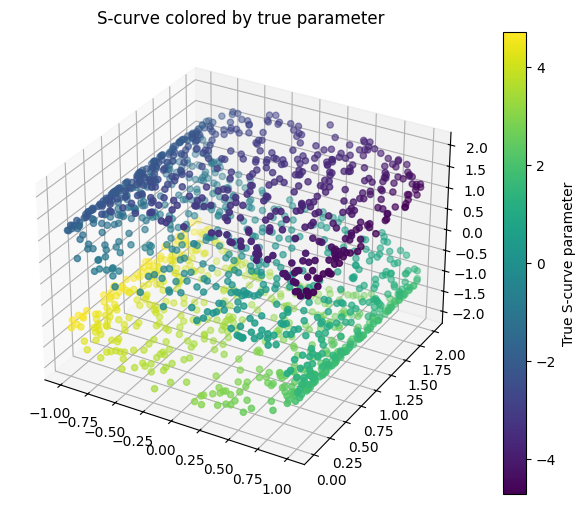

In [3]:
# Plotting the true S manifold and its true color metric.
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=S_true_color, cmap='viridis')
fig.colorbar(p, label='True S-curve parameter')
ax.set_title("S-curve colored by true parameter")
plt.show()

In [4]:
# 3D input

y = my3D_sinusoidal_func(X[:,0],X[:,1], X[:,2])

#y = my3D_linear_func(X[:,0],X[:,1], X[:,2])


fig = go.Figure(data=[go.Scatter3d(
    x=X[:,0],y=X[:,1],z=X[:,2], mode='markers', marker=dict( size=5, color=y, colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

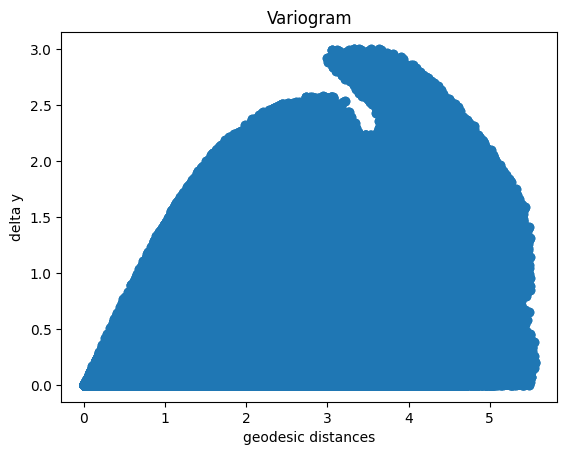

In [5]:
# Calculating the geodesic distance from the original Space

k = 200 #  Adjust as needed
W = kneighbors_graph(X, n_neighbors=k, mode='distance', include_self=False)

distance_full, predecessors = shortest_path(W, directed=False, return_predecessors=True)

my_delta_y = np.abs(np.subtract.outer(y,y))

plt.scatter(distance_full.flatten(),my_delta_y.flatten())
plt.xlabel("geodesic distances")
plt.ylabel("delta y")
plt.title("Variogram")
plt.show()

Text(0.5, 1.0, 'Kernel Matrix Heatmap')

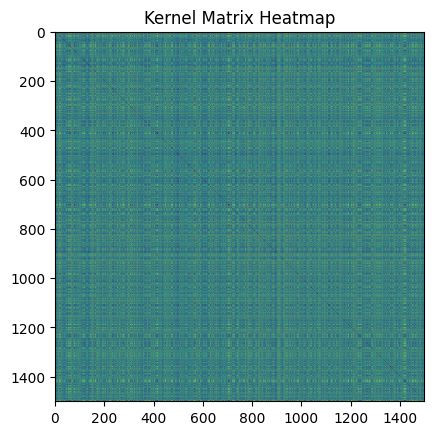

In [6]:
plt.imshow(distance_full)
plt.title('Kernel Matrix Heatmap')

In [7]:
# # Compute the half squared difference matrix
# my_delta_y2 = 0.5 * (np.subtract.outer(y, y)) ** 2

# # Plot the classical semi-variogram
# plt.scatter(geo_dist_matrix_latent_space.flatten(), my_delta_y2.flatten(), alpha=0.3, s=4)
# plt.xlabel('Geodesic distance (latent space)')
# plt.ylabel(r'$\frac{1}{2}(f(x_i) - f(x_j))^2$')
# plt.title('Empirical semi-variogram')
# plt.show()

# GP Model for Predicting the test function values (y)

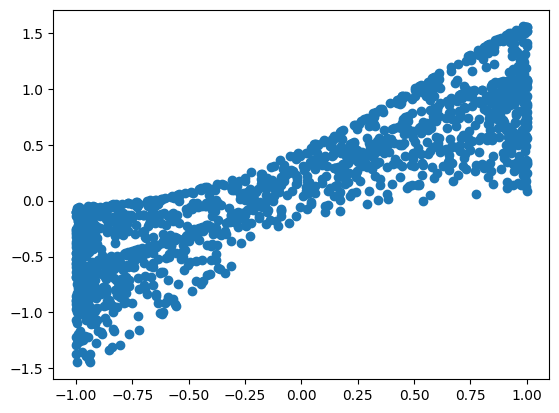

In [8]:
plt.scatter(X[:,0],y)

In [9]:
n_samples = 500

N = X.shape[0]

np.random.seed(1234)
# Randomly select 500 unique indices
train_indices = np.random.choice(N, size=n_samples, replace=False)

# Select test indices that do not overlap with train_indices
remaining_indices = np.setdiff1d(np.arange(N), train_indices)
test_indices = np.random.choice(remaining_indices, size=n_samples, replace=False)

# Extract the random set
x_data_gp = X[train_indices,:]
y_data_gp = y[train_indices]


# Extract the testing data
x_test = X[test_indices,:]
y_test = y[test_indices]


In [10]:
# Training data
fig = go.Figure(data=[go.Scatter3d(
    
    x=x_data_gp[:, 0], y=x_data_gp[:, 1], z=x_data_gp[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=y_data_gp,  # <-- use Himmelblau here!
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Test Function')
    )
)])

fig.update_layout(
    scene=dict(
        aspectmode='cube',
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
    ),
    width=600, height=600,
    margin=dict(r=30, b=20, l=20, t=20)
)
fig.show()

In [11]:
# testing data

fig = go.Figure(data=[go.Scatter3d(
    #x=X[indices, 0], y=X[indices, 1], z=X[indices, 2],
    x=x_test[:, 0], y=x_test[:, 1], z=x_test[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=y_test,  # <-- use Himmelblau here!
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Test Function')
    )
)])

fig.update_layout(
    scene=dict(
        aspectmode='cube',
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
    ),
    width=600, height=600,
    margin=dict(r=30, b=20, l=20, t=20)
)
fig.show()

In [14]:
def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter. Identifies the cutoff after which the covariance becomes 0 when beta=0
    beta: shape parameter. 0 results in a square-like function, larger values cause faster decay
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values


def bump_k(x1, x2, hps):
    
    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    d1 = distance_full[np.ix_(x1_idx, train_indices)]  # Shape: (len(x1), n_train)
    d2 = distance_full[np.ix_(x2_idx, train_indices)]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    # phi_x1[i, :] = embedding of x1[i] based on distances to all training points
    phi_x1 = bump(d1, hps[1], beta=1, ampl=1.0)  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=1.0)  # Shape: (len(x2), n_train)
    
    # RBF on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
    
    kernel_matrix = hps[0] * np.exp(-D_mat**2 / hps[2])
    
    return kernel_matrix


def my_noise(x, hps):
    s = np.ones(len(x)) * 1e-6  
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0
    return m

In [17]:
x_data_gp.shape, y_data_gp.shape

((500, 3), (500,))

In [19]:

# 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
y_var = np.var(y_data_gp)

# 2. Bump radius (hps[1]): [min distance, maximum distance]
train_geodesic = distance_full[np.ix_(train_indices, train_indices)]
non_zero_dists = train_geodesic[train_geodesic > 0]

# Define hyperparameter bounds
bounds = np.empty((3, 2))
# Kernel
bounds[0] = np.array([0.01 * y_var, 10 * y_var])                             # sigma_f: signal variance      
bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # length_scale: bump radius
bounds[2] = np.array([0.01, 100])                                            # length_scale for RBF on embeddings

# # Noise
# bounds[2] = np.array([1e-5,100]) 
# # Mean
# bounds[3] = np.array([np.min(y_data_gp),np.max(y_data_gp)])

init_hps = np.mean(bounds,axis=1)

my_gpo = GPOptimizer(train_indices.reshape(-1,1,),y_data_gp,
                     init_hyperparameters = init_hps,
                     kernel_function = bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                     )

my_gpo.train(hyperparameter_bounds = bounds, init_hyperparameters = init_hps, method='mcmc', max_iter = 4000)

print("GP Training Complete!")

my_gpo.get_hyperparameters()

GP Training Complete!


array([ 0.20844068,  3.77379177, 85.65413175])

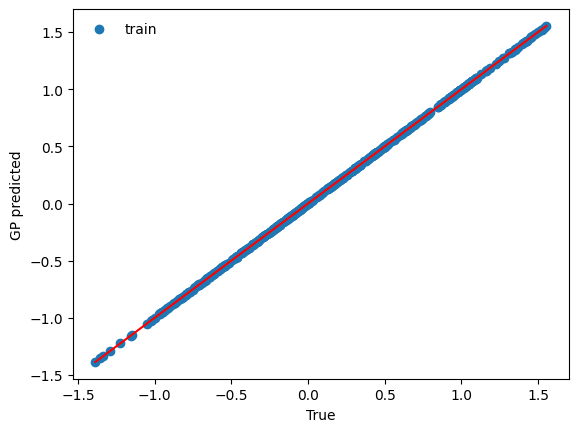

In [21]:
f_train = my_gpo.posterior_mean(train_indices.reshape(-1,1))["m(x)"]

my_line = np.linspace(np.min(y_data_gp),np.max(y_data_gp),10)

plt.scatter(y_data_gp,f_train,label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [23]:
fig = go.Figure(data=[go.Scatter3d(
    
    x=x_data_gp[:, 0], y=x_data_gp[:, 1], z=x_data_gp[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=f_train,  # <-- use Himmelblau here!
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Test Function')
    )
)])

fig.update_layout(
    scene=dict(
        aspectmode='cube',
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
    ),
    width=600, height=600,
    margin=dict(r=30, b=20, l=20, t=20)
)
fig.show()

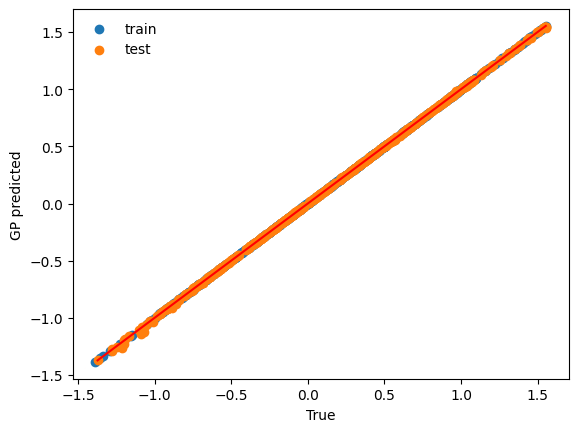

In [22]:
#x_pred = np.linspace(-30,40,100).reshape(-1,1)
#x_test_sorted = np.sort(x_test[:,0]).reshape(-1,1)
f = my_gpo.posterior_mean(test_indices.reshape(-1,1))["m(x)"]
f_train = my_gpo.posterior_mean(train_indices.reshape(-1,1))["m(x)"]

# plt.scatter(x_test_sorted[:,0],f,c='blue')
# plt.scatter(x_data_gp,y_data_gp,c='red')
# plt.scatter(x_data_gp,f_train,c='magenta')

my_line = np.linspace(np.min(y_test),np.max(y_data_gp),10)

plt.scatter(y_data_gp,f_train,label = 'train')
plt.scatter(y_test,f,label = 'test')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [ ]:
# RMSE and CRPS measures

my_rmse = my_gpo.rmse(test_indices.reshape(-1,1),y_test) * 100/ np.mean(y_test)
my_crps = my_gpo.crps(test_indices.reshape(-1,1),y_test)

print("RMSE is: ", my_rmse, "%")
print("CRPS is: ", my_crps)

RMSE is:  4.449146960388583 %
CRPS is:  (np.float64(0.001624416054269505), np.float64(0.003895979033798822))
